# 🏠 Predicting House Prices with Linear Regression
## Oasis Infobyte — Data Analytics Internship
### Level 2 | Project 1

**Intern:** Maddali Naga Durga Niharika  
**College:** VVIT  
**Domain:** Data Analytics  

---

### 📌 Objective
To build a predictive model using Linear Regression to estimate house prices
based on relevant features — providing hands-on experience in developing,
evaluating, and interpreting a predictive model.

### 📂 Datasets Used
| # | Dataset | Source |
|---|---------|--------|
| 1 | California Housing Prices | Kaggle |
| 2 | House Prices Advanced Regression | Kaggle |

### 🛠️ Tools & Libraries
`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn` `Scikit-learn` `Google Colab`

In [5]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [8]:
# ============================================================
# STEP 2: Upload Datasets
# ============================================================

from google.colab import files  # ← ee line add cheyandi!
import io

# --- Dataset 1: California Housing ---
print("📂 Upload Dataset 1: housing.csv")
uploaded1 = files.upload()
df1 = pd.read_csv(io.BytesIO(list(uploaded1.values())[0]))
print(f"✅ Dataset 1 loaded: {df1.shape[0]:,} rows | {df1.shape[1]} columns")

print("\n📂 Upload Dataset 2: Housing.csv")
uploaded2 = files.upload()
df2 = pd.read_csv(io.BytesIO(list(uploaded2.values())[0]))
print(f"✅ Dataset 2 loaded: {df2.shape[0]:,} rows | {df2.shape[1]} columns")

print("\n✅ Both datasets loaded successfully!")

📂 Upload Dataset 1: housing.csv


Saving housing.csv to housing.csv
✅ Dataset 1 loaded: 20,640 rows | 10 columns

📂 Upload Dataset 2: Housing.csv


Saving Housing.csv to Housing.csv
✅ Dataset 2 loaded: 545 rows | 13 columns

✅ Both datasets loaded successfully!


In [9]:
# ============================================================
# STEP 4: Explore Both Datasets
# ============================================================

print("=" * 50)
print("📊 CALIFORNIA HOUSING — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df1.head())

print("\n🔹 Missing Values:")
missing1 = df1.isnull().sum()
missing_pct1 = (df1.isnull().sum() / len(df1) * 100).round(2)
missing_df1 = pd.DataFrame({
    'Missing Count': missing1,
    'Missing %': missing_pct1
}).query('`Missing Count` > 0')
print(missing_df1)

print(f"\n🔹 Duplicate Rows: {df1.duplicated().sum()}")
print("\n🔹 Statistical Summary:")
display(df1.describe())

print("\n" + "=" * 50)
print("📊 HOUSE PRICES ADVANCED — OVERVIEW")
print("=" * 50)

print("\n🔹 First 5 Rows:")
display(df2.head())

print("\n🔹 Missing Values:")
missing2 = df2.isnull().sum()
missing_pct2 = (df2.isnull().sum() / len(df2) * 100).round(2)
missing_df2 = pd.DataFrame({
    'Missing Count': missing2,
    'Missing %': missing_pct2
}).query('`Missing Count` > 0')
print(missing_df2)

print(f"\n🔹 Duplicate Rows: {df2.duplicated().sum()}")
print("\n🔹 Statistical Summary:")
display(df2.describe())

📊 CALIFORNIA HOUSING — OVERVIEW

🔹 First 5 Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



🔹 Missing Values:
                Missing Count  Missing %
total_bedrooms            207        1.0

🔹 Duplicate Rows: 0

🔹 Statistical Summary:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000



📊 HOUSE PRICES ADVANCED — OVERVIEW

🔹 First 5 Rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



🔹 Missing Values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

🔹 Duplicate Rows: 0

🔹 Statistical Summary:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [10]:
# ============================================================
# STEP 5: Data Cleaning
# ============================================================

# --- Dataset 1: California Housing ---
df1_clean = df1.copy()

# Handle missing values
df1_clean['total_bedrooms'].fillna(df1_clean['total_bedrooms'].median(), inplace=True)

# Remove duplicates
before1 = df1_clean.shape[0]
df1_clean.drop_duplicates(inplace=True)
after1 = df1_clean.shape[0]

print("=" * 50)
print("✅ CALIFORNIA HOUSING — CLEANING COMPLETE")
print("=" * 50)
print(f"  Duplicates Removed : {before1 - after1}")
print(f"  Missing Values Left: {df1_clean.isnull().sum().sum()}")
print(f"  Final Shape        : {df1_clean.shape}")

# --- Dataset 2: House Prices Advanced ---
df2_clean = df2.copy()

# Handle missing values — fill with median
for col in df2_clean.select_dtypes(include=[np.number]).columns:
    df2_clean[col].fillna(df2_clean[col].median(), inplace=True)

# Remove duplicates
before2 = df2_clean.shape[0]
df2_clean.drop_duplicates(inplace=True)
after2 = df2_clean.shape[0]

print("\n" + "=" * 50)
print("✅ HOUSE PRICES ADVANCED — CLEANING COMPLETE")
print("=" * 50)
print(f"  Duplicates Removed : {before2 - after2}")
print(f"  Missing Values Left: {df2_clean.isnull().sum().sum()}")
print(f"  Final Shape        : {df2_clean.shape}")

✅ CALIFORNIA HOUSING — CLEANING COMPLETE
  Duplicates Removed : 0
  Missing Values Left: 0
  Final Shape        : (20640, 10)

✅ HOUSE PRICES ADVANCED — CLEANING COMPLETE
  Duplicates Removed : 0
  Missing Values Left: 0
  Final Shape        : (545, 13)


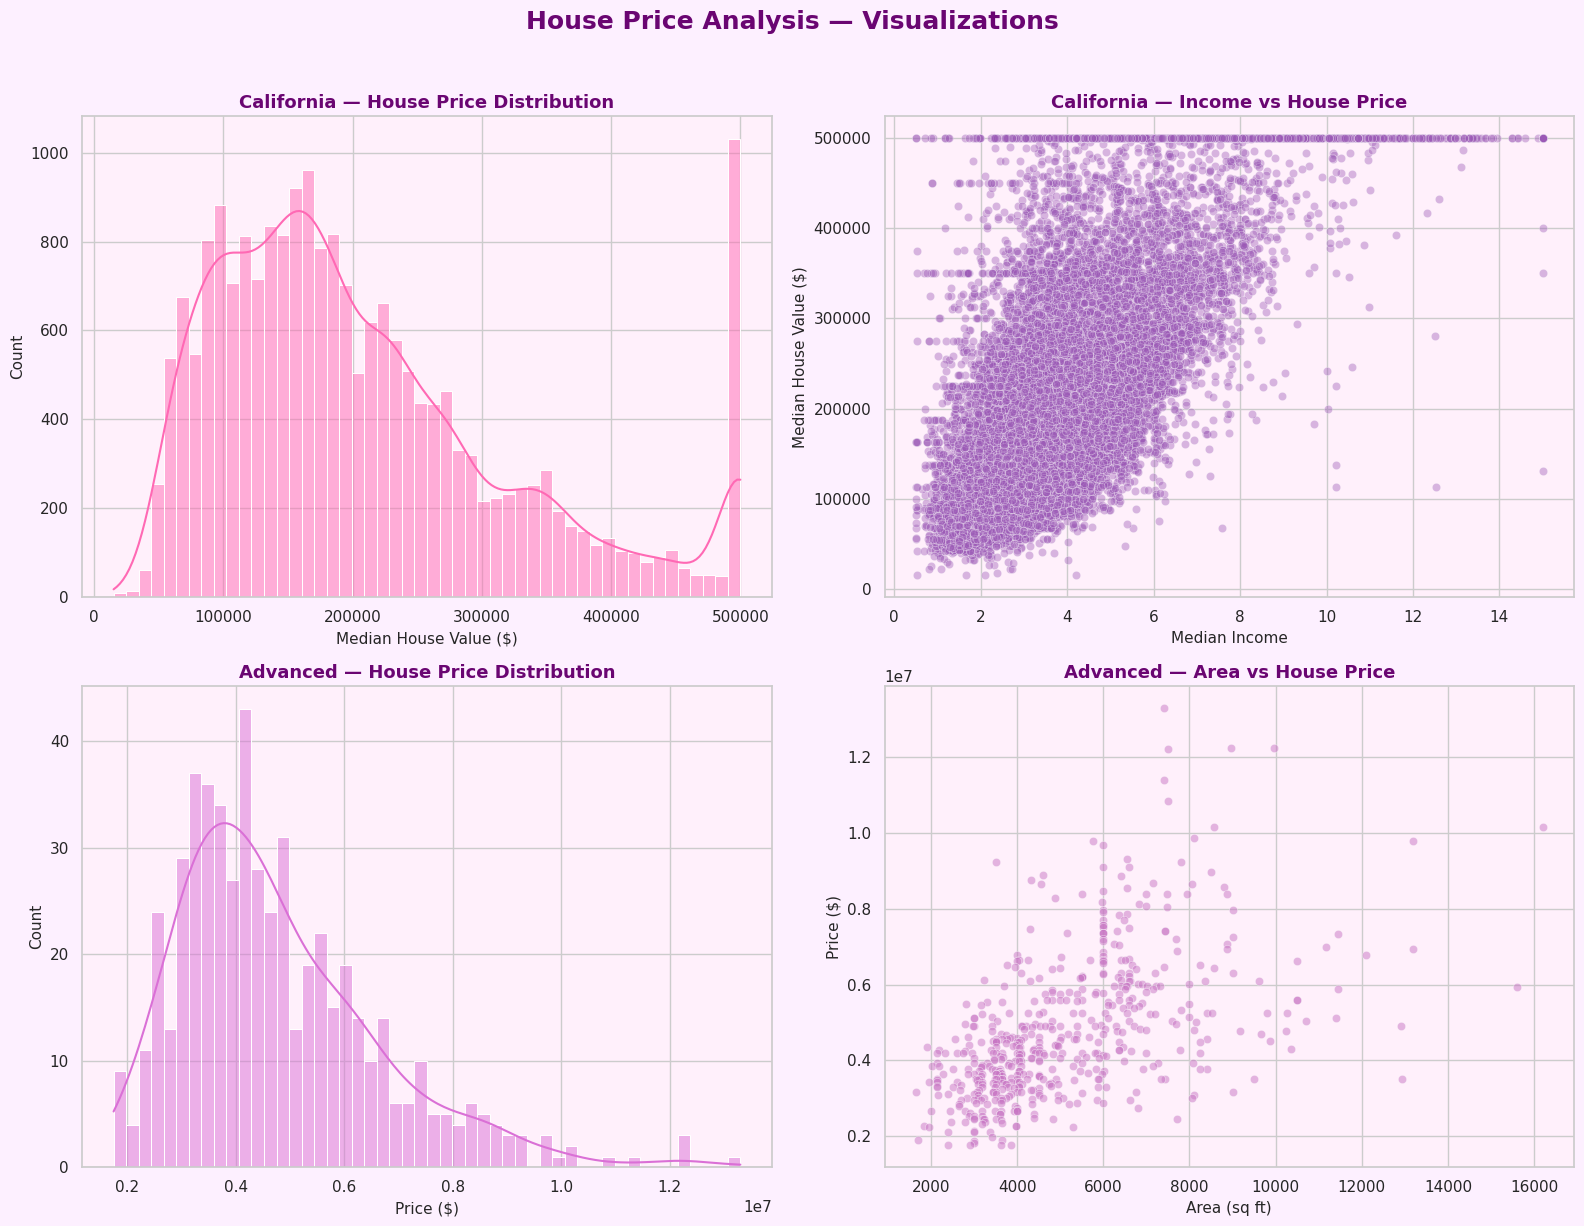

✅ Visualizations saved! 🌸💜


In [11]:
# ============================================================
# STEP 6: Data Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('House Price Analysis — Visualizations',
             fontsize=18, fontweight='bold', color='#6A0572', y=1.02)

# --- Plot 1: California — House Price Distribution ---
axes[0, 0].set_facecolor('#FFF0FB')
sns.histplot(df1_clean['median_house_value'], bins=50,
             color='#FF69B4', ax=axes[0, 0], kde=True)
axes[0, 0].set_title('California — House Price Distribution',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[0, 0].set_xlabel('Median House Value ($)', fontsize=11)
axes[0, 0].set_ylabel('Count', fontsize=11)

# --- Plot 2: California — Income vs Price ---
axes[0, 1].set_facecolor('#FFF0FB')
sns.scatterplot(data=df1_clean, x='median_income',
                y='median_house_value', color='#9B59B6',
                alpha=0.4, ax=axes[0, 1])
axes[0, 1].set_title('California — Income vs House Price',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[0, 1].set_xlabel('Median Income', fontsize=11)
axes[0, 1].set_ylabel('Median House Value ($)', fontsize=11)

# --- Plot 3: Advanced — House Price Distribution ---
axes[1, 0].set_facecolor('#FFF0FB')
sns.histplot(df2_clean['price'], bins=50,
             color='#DA70D6', ax=axes[1, 0], kde=True)
axes[1, 0].set_title('Advanced — House Price Distribution',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[1, 0].set_xlabel('Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Count', fontsize=11)

# --- Plot 4: Advanced — Area vs Price ---
axes[1, 1].set_facecolor('#FFF0FB')
sns.scatterplot(data=df2_clean, x='area',
                y='price', color='#C875C4',
                alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Advanced — Area vs House Price',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[1, 1].set_xlabel('Area (sq ft)', fontsize=11)
axes[1, 1].set_ylabel('Price ($)', fontsize=11)

plt.tight_layout()
plt.savefig('house_price_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#FDF0FF')
plt.show()
print("✅ Visualizations saved! 🌸💜")

In [12]:
# ============================================================
# STEP 7: Feature Selection & Model Building
# ============================================================

# --- Dataset 1: California Housing ---
print("=" * 50)
print("🏠 CALIFORNIA HOUSING — LINEAR REGRESSION")
print("=" * 50)

# Select numeric features only
features1 = ['median_income', 'housing_median_age', 'total_rooms',
             'total_bedrooms', 'population', 'households', 'latitude', 'longitude']
target1 = 'median_house_value'

X1 = df1_clean[features1]
y1 = df1_clean[target1]

# Train Test Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Scale features
scaler1 = StandardScaler()
X1_train_scaled = scaler1.fit_transform(X1_train)
X1_test_scaled = scaler1.transform(X1_test)

# Train model
lr1 = LinearRegression()
lr1.fit(X1_train_scaled, y1_train)
y1_pred = lr1.predict(X1_test_scaled)

# Evaluate
r2_1 = r2_score(y1_test, y1_pred)
mse_1 = mean_squared_error(y1_test, y1_pred)
mae_1 = mean_absolute_error(y1_test, y1_pred)
rmse_1 = np.sqrt(mse_1)

print(f"\n🔹 R² Score : {r2_1:.4f}")
print(f"🔹 MAE      : ${mae_1:,.2f}")
print(f"🔹 MSE      : ${mse_1:,.2f}")
print(f"🔹 RMSE     : ${rmse_1:,.2f}")

# --- Dataset 2: House Prices Advanced ---
print("\n" + "=" * 50)
print("🏠 HOUSE PRICES ADVANCED — LINEAR REGRESSION")
print("=" * 50)

# Select numeric features
num_cols2 = df2_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols2.remove('price')
features2 = num_cols2
target2 = 'price'

X2 = df2_clean[features2]
y2 = df2_clean[target2]

# Train Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Scale features
scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

# Train model
lr2 = LinearRegression()
lr2.fit(X2_train_scaled, y2_train)
y2_pred = lr2.predict(X2_test_scaled)

# Evaluate
r2_2 = r2_score(y2_test, y2_pred)
mse_2 = mean_squared_error(y2_test, y2_pred)
mae_2 = mean_absolute_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mse_2)

print(f"\n🔹 R² Score : {r2_2:.4f}")
print(f"🔹 MAE      : ${mae_2:,.2f}")
print(f"🔹 MSE      : ${mse_2:,.2f}")
print(f"🔹 RMSE     : ${rmse_2:,.2f}")

🏠 CALIFORNIA HOUSING — LINEAR REGRESSION

🔹 R² Score : 0.6139
🔹 MAE      : $51,810.48
🔹 MSE      : $5,059,928,371.17
🔹 RMSE     : $71,133.17

🏠 HOUSE PRICES ADVANCED — LINEAR REGRESSION

🔹 R² Score : 0.5464
🔹 MAE      : $1,127,483.35
🔹 MSE      : $2,292,721,545,725.37
🔹 RMSE     : $1,514,173.55


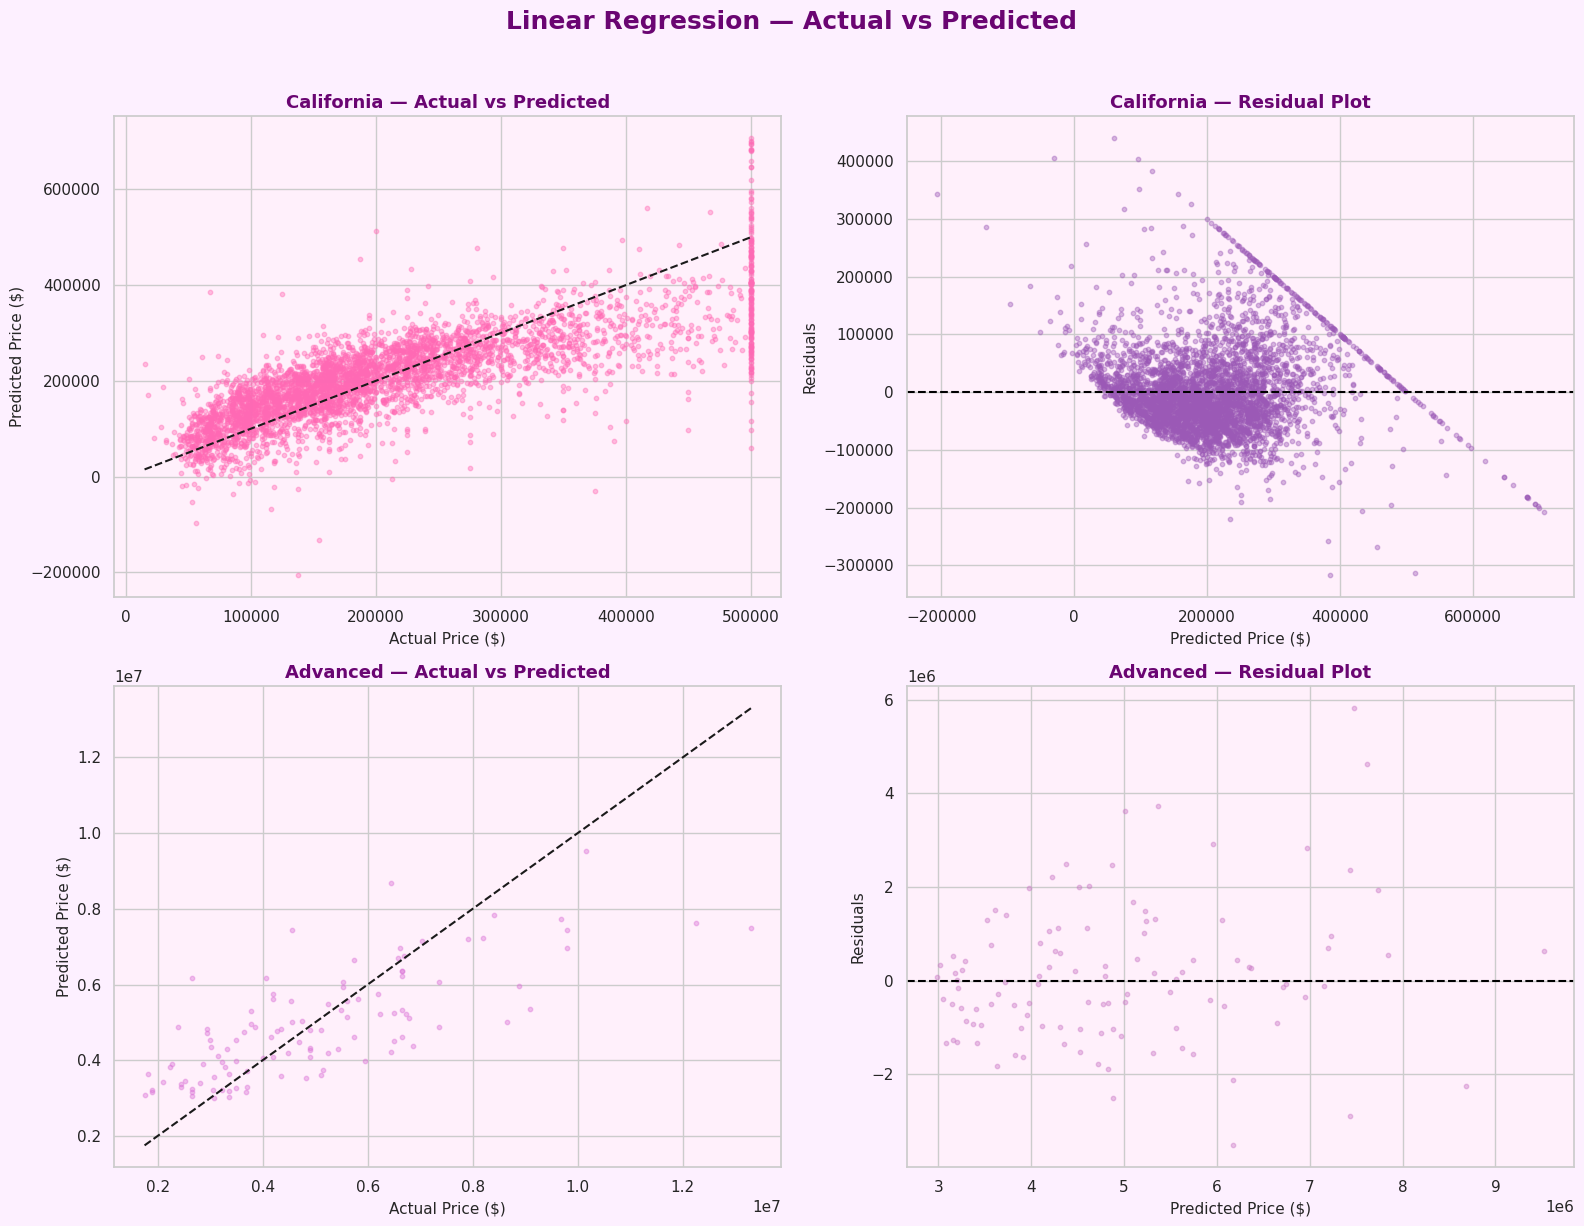

✅ Actual vs Predicted plots saved! 🌸💜


In [13]:
# ============================================================
# STEP 8: Actual vs Predicted Visualization
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Linear Regression — Actual vs Predicted',
             fontsize=18, fontweight='bold', color='#6A0572', y=1.02)

# --- Plot 1: California — Actual vs Predicted ---
axes[0, 0].set_facecolor('#FFF0FB')
axes[0, 0].scatter(y1_test, y1_pred, color='#FF69B4', alpha=0.4, s=10)
axes[0, 0].plot([y1_test.min(), y1_test.max()],
                [y1_test.min(), y1_test.max()],
                'k--', linewidth=1.5)
axes[0, 0].set_title('California — Actual vs Predicted',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[0, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[0, 0].set_ylabel('Predicted Price ($)', fontsize=11)

# --- Plot 2: California — Residuals ---
residuals1 = y1_test - y1_pred
axes[0, 1].set_facecolor('#FFF0FB')
axes[0, 1].scatter(y1_pred, residuals1, color='#9B59B6', alpha=0.4, s=10)
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('California — Residual Plot',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[0, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[0, 1].set_ylabel('Residuals', fontsize=11)

# --- Plot 3: Advanced — Actual vs Predicted ---
axes[1, 0].set_facecolor('#FFF0FB')
axes[1, 0].scatter(y2_test, y2_pred, color='#DA70D6', alpha=0.4, s=10)
axes[1, 0].plot([y2_test.min(), y2_test.max()],
                [y2_test.min(), y2_test.max()],
                'k--', linewidth=1.5)
axes[1, 0].set_title('Advanced — Actual vs Predicted',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[1, 0].set_xlabel('Actual Price ($)', fontsize=11)
axes[1, 0].set_ylabel('Predicted Price ($)', fontsize=11)

# --- Plot 4: Advanced — Residuals ---
residuals2 = y2_test - y2_pred
axes[1, 1].set_facecolor('#FFF0FB')
axes[1, 1].scatter(y2_pred, residuals2, color='#C875C4', alpha=0.4, s=10)
axes[1, 1].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('Advanced — Residual Plot',
                      fontsize=13, fontweight='bold', color='#6A0572')
axes[1, 1].set_xlabel('Predicted Price ($)', fontsize=11)
axes[1, 1].set_ylabel('Residuals', fontsize=11)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150,
            bbox_inches='tight', facecolor='#FDF0FF')
plt.show()
print("✅ Actual vs Predicted plots saved! 🌸💜")

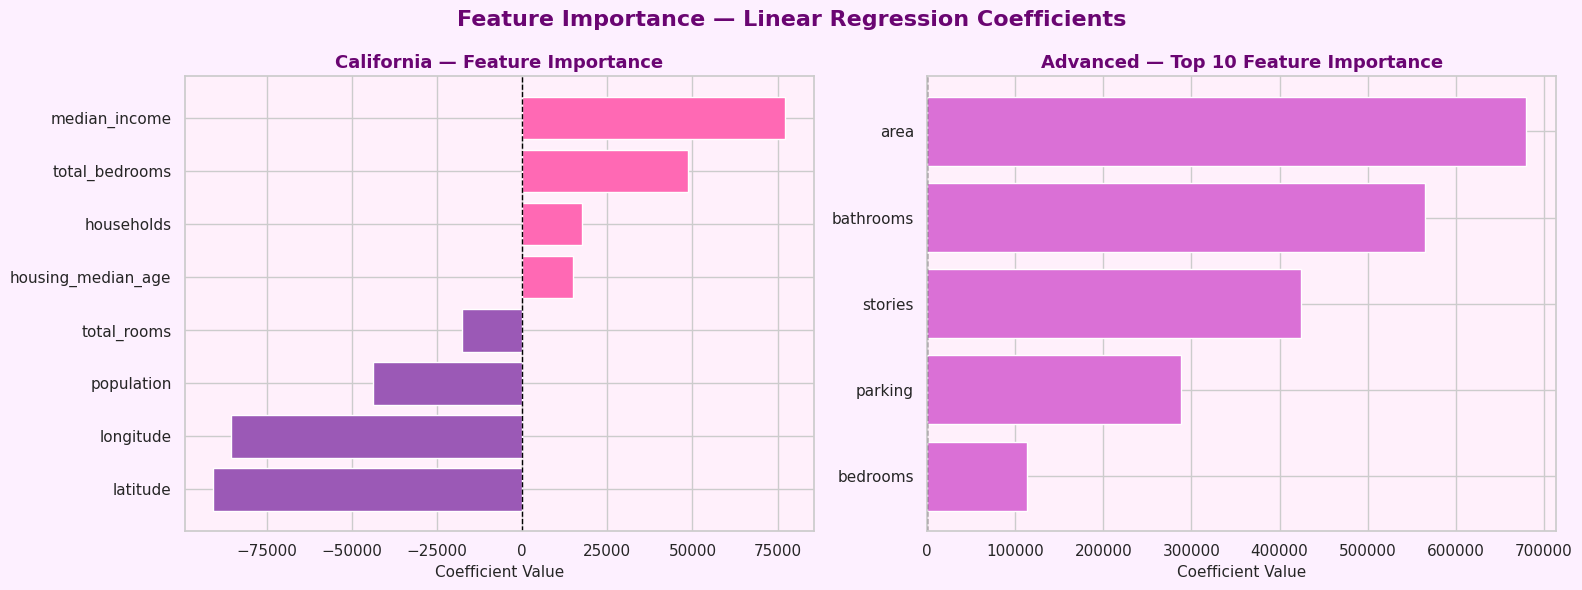

✅ Feature Importance plots saved! 🌸💜


In [14]:
# ============================================================
# STEP 9: Feature Importance
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Feature Importance — Linear Regression Coefficients',
             fontsize=16, fontweight='bold', color='#6A0572')

# --- Dataset 1: California Housing ---
coef1 = pd.DataFrame({
    'Feature': features1,
    'Coefficient': lr1.coef_
}).sort_values('Coefficient', ascending=True)

axes[0].set_facecolor('#FFF0FB')
bars1 = axes[0].barh(coef1['Feature'], coef1['Coefficient'],
                      color=['#FF69B4' if x > 0 else '#9B59B6'
                             for x in coef1['Coefficient']])
axes[0].set_title('California — Feature Importance',
                   fontsize=13, fontweight='bold', color='#6A0572')
axes[0].set_xlabel('Coefficient Value', fontsize=11)
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)

# --- Dataset 2: Advanced Housing ---
coef2 = pd.DataFrame({
    'Feature': features2,
    'Coefficient': lr2.coef_
}).sort_values('Coefficient', ascending=True).tail(10)

axes[1].set_facecolor('#FFF0FB')
bars2 = axes[1].barh(coef2['Feature'], coef2['Coefficient'],
                      color=['#DA70D6' if x > 0 else '#C875C4'
                             for x in coef2['Coefficient']])
axes[1].set_title('Advanced — Top 10 Feature Importance',
                   fontsize=13, fontweight='bold', color='#6A0572')
axes[1].set_xlabel('Coefficient Value', fontsize=11)
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#FDF0FF')
plt.show()
print("✅ Feature Importance plots saved! 🌸💜")

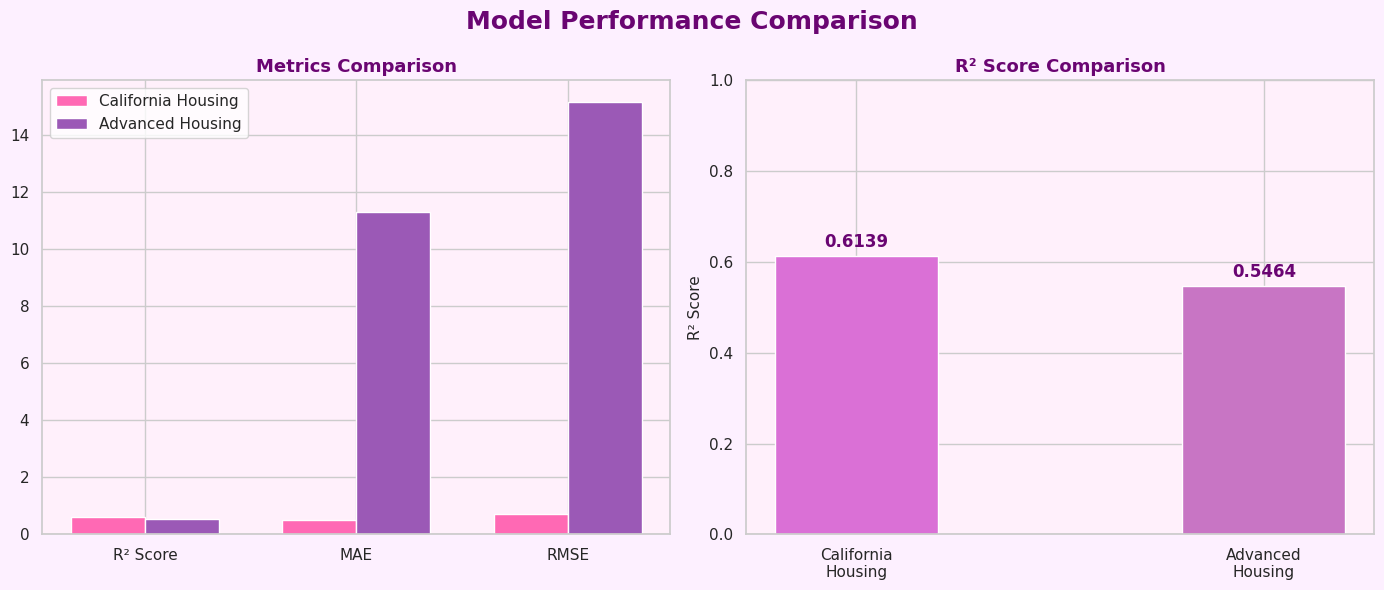

✅ Model Performance chart saved! 🌸💜


In [15]:
# ============================================================
# STEP 10: Model Performance Summary
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#FDF0FF')
fig.suptitle('Model Performance Comparison',
             fontsize=18, fontweight='bold', color='#6A0572')

# --- Metrics Comparison ---
metrics = ['R² Score', 'MAE', 'RMSE']
cal_scores = [r2_1, mae_1/100000, rmse_1/100000]
adv_scores = [r2_2, mae_2/100000, rmse_2/100000]

x = np.arange(len(metrics))
width = 0.35

# --- Plot 1: Bar Comparison ---
axes[0].set_facecolor('#FFF0FB')
bars1 = axes[0].bar(x - width/2, cal_scores, width,
                     label='California Housing',
                     color='#FF69B4', edgecolor='white')
bars2 = axes[0].bar(x + width/2, adv_scores, width,
                     label='Advanced Housing',
                     color='#9B59B6', edgecolor='white')
axes[0].set_title('Metrics Comparison',
                   fontsize=13, fontweight='bold', color='#6A0572')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_facecolor('#FFF0FB')

# --- Plot 2: R² Score Comparison ---
axes[1].set_facecolor('#FFF0FB')
datasets = ['California\nHousing', 'Advanced\nHousing']
r2_scores = [r2_1, r2_2]
colors = ['#DA70D6', '#C875C4']
bars = axes[1].bar(datasets, r2_scores, color=colors,
                    edgecolor='white', width=0.4)
axes[1].set_title('R² Score Comparison',
                   fontsize=13, fontweight='bold', color='#6A0572')
axes[1].set_ylabel('R² Score', fontsize=11)
axes[1].set_ylim(0, 1)
for bar, score in zip(bars, r2_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f'{score:.4f}', ha='center',
                 fontsize=12, fontweight='bold', color='#6A0572')

plt.tight_layout()
plt.savefig('model_performance.png', dpi=150,
            bbox_inches='tight', facecolor='#FDF0FF')
plt.show()
print("✅ Model Performance chart saved! 🌸💜")

In [16]:
# ============================================================
# STEP 11: Save & Download All Files
# ============================================================

from google.colab import files

# Save predictions
df1_clean['predicted_price'] = lr1.predict(
    scaler1.transform(df1_clean[features1])
)
df2_clean['predicted_price'] = lr2.predict(
    scaler2.transform(df2_clean[features2])
)

# Save CSVs
df1_clean.to_csv('california_housing_predictions.csv', index=False)
df2_clean.to_csv('advanced_housing_predictions.csv', index=False)

print("✅ Files saved!")
print(f"   california_housing_predictions.csv → {df1_clean.shape[0]:,} rows")
print(f"   advanced_housing_predictions.csv   → {df2_clean.shape[0]:,} rows")

# Download all files
files.download('california_housing_predictions.csv')
files.download('advanced_housing_predictions.csv')
files.download('house_price_analysis.png')
files.download('actual_vs_predicted.png')
files.download('feature_importance.png')
files.download('model_performance.png')

print("\n✅ All files downloaded! 🌸💜")

✅ Files saved!
   california_housing_predictions.csv → 20,640 rows
   advanced_housing_predictions.csv   → 545 rows


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded! 🌸💜
